In [19]:
# import ML libraries and configure plotting defaults.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Import custom modules for preprocessing and modeling.
# import sys
# sys.path.append('../src')
# from preprocessing import scale_features
# from models import train_logistic_regression, train_random_forest

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [20]:
# load dataset and preview its structure.
# Load the dataset
df = pd.read_csv('../data/raw/diabetes_health_indicators.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Dataset loaded successfully!
Shape: (253680, 22)

First few rows:
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0

In [21]:
# prepare dataset by handling nulls and separating X/y.
# Handle missing values (if any)
df = df.dropna()

# Separate features and target (fixed by project proposal)
target_col = 'Diabetes_binary'
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found. Available columns: {list(df.columns)}")

X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Target variable: {target_col}")
print(f"Features shape: {X.shape}")
print("Target distribution:")
print(y.value_counts())

Target variable: Diabetes_binary
Features shape: (253680, 21)
Target distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


In [22]:
# create stratified train-test split and inspect sizes.
# Split data into training and testing sets (stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print("\nTraining set target distribution:")
print(y_train.value_counts())

Training set size: (202944, 21)
Testing set size: (50736, 21)

Training set target distribution:
Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64


In [23]:
# standardize features using StandardScaler.
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully using StandardScaler!")

Features scaled successfully using StandardScaler!


In [24]:
# train Logistic Regression and generate predictions.
# Train Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_y_pred = lr_model.predict(X_test_scaled)
lr_y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully!")

Training Logistic Regression...
Logistic Regression trained successfully!


In [25]:
# compute Logistic Regression evaluation metrics.
# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, lr_y_pred)
lr_precision = precision_score(y_test, lr_y_pred, zero_division=0)
lr_recall = recall_score(y_test, lr_y_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_y_pred, zero_division=0)
lr_roc_auc = roc_auc_score(y_test, lr_y_pred_proba)
lr_cm = confusion_matrix(y_test, lr_y_pred)

print("LOGISTIC REGRESSION METRICS")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_roc_auc:.4f}")
print(f"\nConfusion Matrix:\n{lr_cm}")


LOGISTIC REGRESSION METRICS
Accuracy:  0.8621
Precision: 0.5171
Recall:    0.1583
F1-Score:  0.2424
ROC-AUC:   0.8192

Confusion Matrix:
[[42622  1045]
 [ 5950  1119]]


In [26]:
# run cross-validation for Logistic Regression.
# Cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    X_train_scaled, y_train, cv=5, scoring='accuracy'
)

print("Logistic Regression - Cross-Validation Scores:")
print(f"Scores: {lr_cv_scores}")
print(f"Mean: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})\n")

Logistic Regression - Cross-Validation Scores:
Scores: [0.86378083 0.86309099 0.86424893 0.86405184 0.86394994]
Mean: 0.8638 (+/- 0.0004)



In [27]:
# train Random Forest and generate predictions.
# Train Random Forest
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_model.fit(X_train, y_train)  # Note: Random Forest doesn't require scaled features

# Make predictions
rf_y_pred = rf_model.predict(X_test)
rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Training Random Forest Classifier...
Random Forest trained successfully!


In [28]:
# compute Random Forest evaluation metrics on test data.
# Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_y_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_y_pred, zero_division=0)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred_proba)
rf_cm = confusion_matrix(y_test, rf_y_pred)

print("RANDOM FOREST METRICS")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")
print(f"\nConfusion Matrix:\n{rf_cm}")


RANDOM FOREST METRICS
Accuracy:  0.8596
Precision: 0.4892
Recall:    0.1787
F1-Score:  0.2617
ROC-AUC:   0.7963

Confusion Matrix:
[[42348  1319]
 [ 5806  1263]]


In [29]:
# run cross-validation for Random Forest.
# Cross-validation for Random Forest
rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, y_train, cv=5, scoring='accuracy'
)

print("Random Forest - Cross-Validation Scores:")
print(f"Scores: {rf_cv_scores}")
print(f"Mean: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

Random Forest - Cross-Validation Scores:
Scores: [0.85954323 0.85986351 0.85956786 0.85974032 0.86084557]
Mean: 0.8599 (+/- 0.0005)


In [30]:
# create tabular metric comparison between models.
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc]
})

print("\nMODEL COMPARISON")
print(comparison_df.to_string(index=False))



MODEL COMPARISON
   Metric  Logistic Regression  Random Forest
 Accuracy             0.862129       0.859567
Precision             0.517098       0.489156
   Recall             0.158297       0.178667
 F1-Score             0.242391       0.261735
  ROC-AUC             0.819163       0.796321


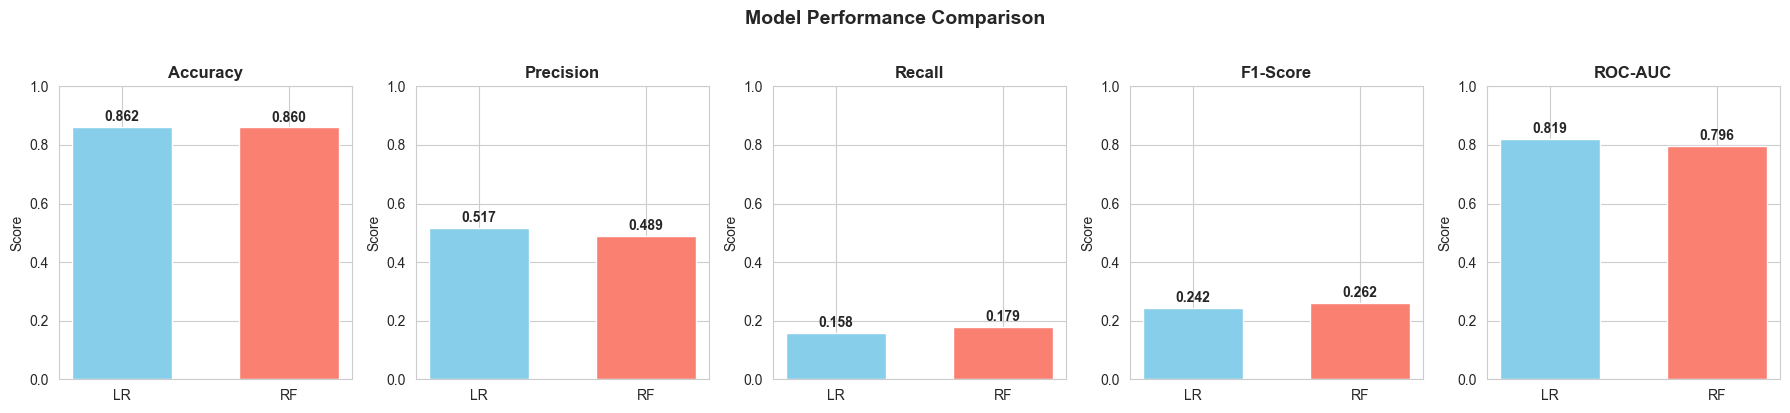

In [31]:
# compare core metrics with side-by-side bar charts.
# Plot metric comparison
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_values = [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc]
rf_values = [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc]

for idx, (metric, lr_val, rf_val) in enumerate(zip(metrics, lr_values, rf_values)):
    x = [0, 1]
    y = [lr_val, rf_val]
    colors = ['skyblue', 'salmon']
    axes[idx].bar(x, y, color=colors, width=0.6)
    axes[idx].set_ylim([0, 1])
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['LR', 'RF'], fontsize=10)
    axes[idx].set_ylabel('Score')
    
    # Add value labels on bars
    for i, v in enumerate(y):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

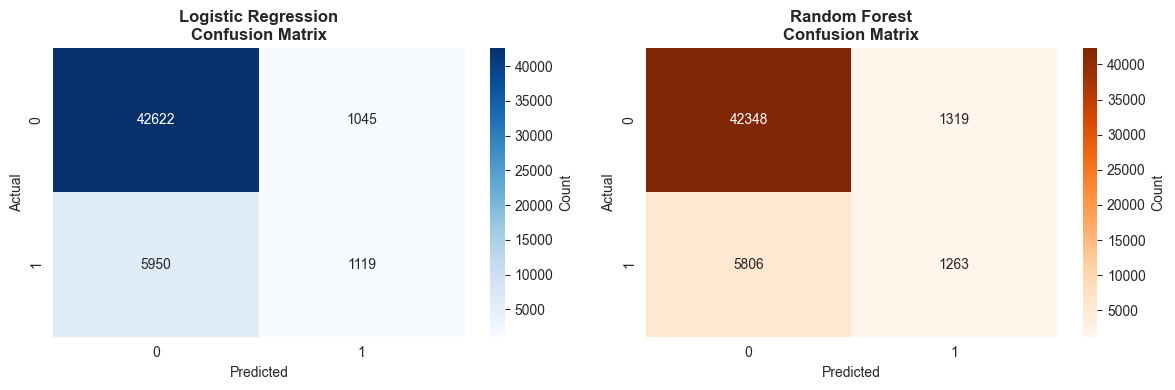

In [32]:
# visualize confusion matrices for both models.
# Confusion matrices comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression confusion matrix
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Count'})
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest confusion matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            cbar_kws={'label': 'Count'})
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

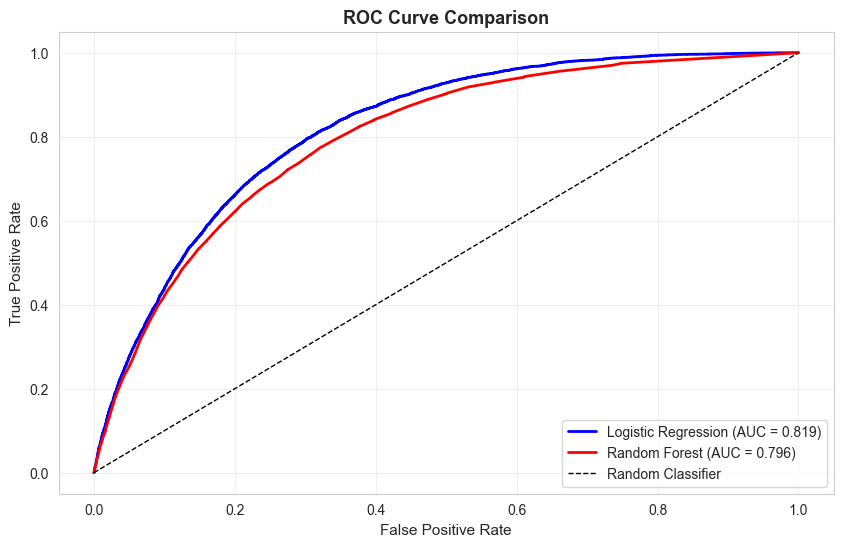

In [33]:
# plot ROC curves for Logistic Regression and Random Forest.
# ROC curves comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_y_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_roc_auc:.3f})', 
         linewidth=2, color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_roc_auc:.3f})', 
         linewidth=2, color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [34]:
# compute and print Random Forest feature-importance table.
# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features (Random Forest):")
print(feature_importance.head(10).to_string(index=False))

Top 10 Most Important Features (Random Forest):
  Feature  Importance
      BMI    0.182943
      Age    0.123470
   Income    0.097888
 PhysHlth    0.084095
Education    0.070264
  GenHlth    0.069949
 MentHlth    0.064255
   HighBP    0.043395
   Fruits    0.032912
   Smoker    0.032845


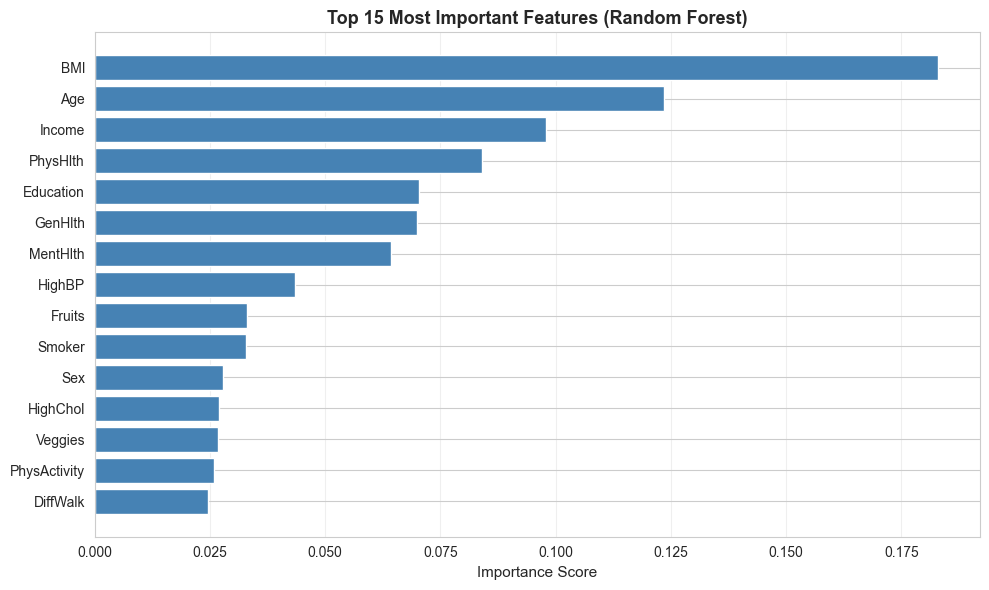

In [35]:
# plot top Random Forest feature importances.
# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values, color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance Score', fontsize=11)
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# print final model performance summary and conclusions.
print("FINAL SUMMARY")

better_model = "Random Forest" if rf_accuracy > lr_accuracy else "Logistic Regression"
print(f"\nBest Overall Model: {better_model}")
print(f"\nLogistic Regression Performance:")
print(f"  - Accuracy:  {lr_accuracy:.4f}")
print(f"  - F1-Score:  {lr_f1:.4f}")
print(f"  - ROC-AUC:   {lr_roc_auc:.4f}")
print(f"  - CV Score:  {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

print(f"\nRandom Forest Performance:")
print(f"  - Accuracy:  {rf_accuracy:.4f}")
print(f"  - F1-Score:  {rf_f1:.4f}")
print(f"  - ROC-AUC:   {rf_roc_auc:.4f}")
print(f"  - CV Score:  {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

print(f"\nKey Insights:")
print(f"  1. Model with higher ROC-AUC handles class imbalance better")
print(f"  2. Cross-validation score indicates model generalization")
print(f"  3. Top predictive feature: {feature_importance.iloc[0]['Feature']}")



FINAL SUMMARY

Best Overall Model: Logistic Regression

Logistic Regression Performance:
  - Accuracy:  0.8621
  - F1-Score:  0.2424
  - ROC-AUC:   0.8192
  - CV Score:  0.8638 ± 0.0004

Random Forest Performance:
  - Accuracy:  0.8596
  - F1-Score:  0.2617
  - ROC-AUC:   0.7963
  - CV Score:  0.8599 ± 0.0005

Key Insights:
  1. Model with higher ROC-AUC handles class imbalance better
  2. Cross-validation score indicates model generalization
  3. Top predictive feature: BMI
